In [13]:
import numpy as np
import matplotlib.pyplot as plt
cmap = 'tab10'
import pandas as pd


import pickle
from scipy.spatial.distance import cdist, pdist, squareform
from sklearn.metrics import rand_score, confusion_matrix

from openTSNE import TSNE
from phate import PHATE
from sklearn.manifold import Isomap
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from umap import UMAP

import sys
sys.path.append('../code')
from align import *
from embed import *
from eval import *


import time

# Generate data

In [14]:
d = 10 #dimension
k = 10  # number of clusters
n = 5000  # total number of samples

sep = 1.25 * np.sqrt(d)  # separation between clusters

# cluster counts
cluster_counts = np.random.multinomial(n, [1/k]*k)

# placeholder
X = np.zeros((1, d))
labels = []

for i in range(k):
    mu = np.zeros(d)
    mu[i] = sep

    X1 = np.random.multivariate_normal(mu, np.eye(d), cluster_counts[i])
    X = np.vstack((X, X1))

    labels.extend([i + 1] * cluster_counts[i])  # +1 to match R labels

# drop placeholder row
data = X[1:n+1, :]
labels = np.array(labels) - 1

In [15]:
#save data
df = pd.DataFrame(np.hstack((data,labels.reshape(-1,1))))
df.to_csv('../data/gmm.csv')

In [16]:
df = pd.read_csv('../data/gmm.csv')

In [17]:
labels = df['10'].to_numpy()
data = df.iloc[:,1:11].to_numpy()

## Cluster

In [18]:
st = time.time()
clusters = KMeans(n_clusters=10).fit_predict(data)
np.unique(clusters, return_counts = True)
time.time()-st

1.7966721057891846

In [19]:
rand_score(labels, clusters)

0.9940460892178435

In [20]:
n = 5000

## Embed

In [21]:
st = time.time()
pca  = PCA(n_components = 2)
embeddings = np.zeros((n,2))
for i in range(max(clusters)+1):
    idxs = labels == i
    embeddings[idxs,:] = pca.fit_transform(data[idxs,:])
time.time()-st

0.012156486511230469

## Align

In [22]:
st = time.time()
distances = {}
n_clusters = len(np.unique(clusters))
for i in range(n_clusters):
    cluster_i = data[clusters == i,]
    for j in range(i+1, n_clusters):
        cluster_j = data[clusters == j,:]
        distances[i,j] = cdist(cluster_i, cluster_j)
time.time()-st

0.0745229721069336

In [23]:
st = time.time()
out = Embedding(embeddings, clusters, distances, alpha =1)
ce_emb = out.align_embedding(m = 50)
time.time()-st

8.160006046295166

In [24]:
out.get_default_alpha()

1.647427690220415

([<matplotlib.axis.YTick at 0x1ab9e2a8590>,
 [Text(0, -9.0, '−9'),
  Text(0, -6.0, '−6'),
  Text(0, -3.0, '−3'),
  Text(0, 0.0, '0'),
  Text(0, 3.0, '3'),
  Text(0, 6.0, '6'),
  Text(0, 9.0, '9')])

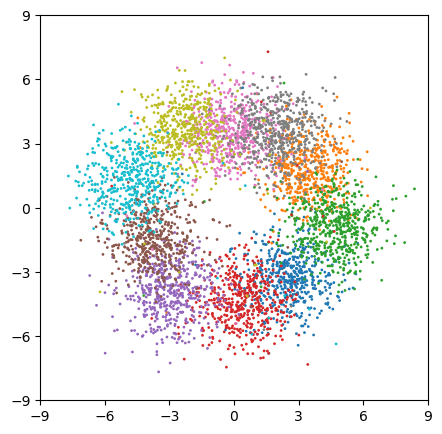

In [25]:
plt.figure(figsize = [5,5])
plt.scatter(ce_emb[:,0], ce_emb[:,1], c = labels, cmap = cmap, s = 1)

plt.xlim(-9,9)
plt.ylim(-9,9)
plt.xticks(np.linspace(-9,9,7))
plt.yticks(np.linspace(-9,9,7))
# plt.savefig('../figures/gmm/ce_1.png', format='png', dpi=300, bbox_inches='tight')

In [26]:
st = time.time()
out = Embedding(embeddings, clusters, distances, alpha =2)
ce_emb_2 = out.align_embedding(m = 50)
time.time()-st

7.170084476470947

In [1]:
plt.figure(figsize = [5,5])
plt.scatter(ce_emb_2[:,0], ce_emb_2[:,1], c = labels, cmap = cmap, s = 1)
plt.xlim(-15,15)
plt.ylim(-15,15)
plt.xticks(np.linspace(-15,15,7))
plt.yticks(np.linspace(-15,15,7))
plt.savefig('../figures/gmm/ce_2.png', format='png', dpi=300, bbox_inches='tight')

In [28]:
st = time.time()
out = Embedding(embeddings, clusters, distances, alpha =1.65)
ce_emb_165 = out.align_embedding(m = 50)
time.time()-st

8.282301425933838

In [2]:
plt.figure(figsize = [5,5])
plt.scatter(ce_emb_165[:,0], ce_emb_165[:,1], c = labels, cmap = cmap, s = 1)
plt.xlim(-12,12)
plt.ylim(-12,12)
plt.xticks(np.linspace(-12,12,7))
plt.yticks(np.linspace(-12,12,7))
# plt.savefig('../figures/gmm/ce_165.png', format='png', dpi=300, bbox_inches='tight')

# Other methods

In [30]:
st = time.time()
tsne30 = TSNE(perplexity = 30).fit(data)
tsne30 = np.array(tsne30)
time.time()-st

17.986995458602905

([<matplotlib.axis.YTick at 0x1ab9e2a9c50>,
 [Text(0, -81.0, '−81'),
  Text(0, -54.0, '−54'),
  Text(0, -27.0, '−27'),
  Text(0, 0.0, '0'),
  Text(0, 27.0, '27'),
  Text(0, 54.0, '54'),
  Text(0, 81.0, '81')])

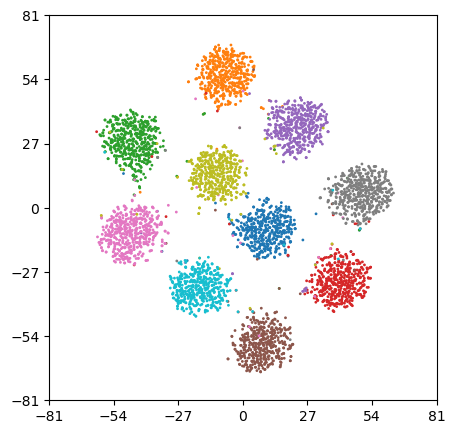

In [31]:
plt.figure(figsize = [5,5])
plt.scatter(tsne30[:,0], tsne30[:,1], c = labels, cmap = cmap, s = 1)
plt.xlim(-81,81)
plt.ylim(-81,81)
plt.xticks(np.linspace(-81,81,7))
plt.yticks(np.linspace(-81,81,7))
plt.savefig('../figures/gmm/tsne.png', format='png', dpi=300, bbox_inches='tight')

In [32]:
st = time.time()
pca = PCA(n_components = 2).fit_transform(data)
time.time()-st

0.0

([<matplotlib.axis.YTick at 0x1ab9b6c6710>,
 [Text(0, -6.0, '−6'),
  Text(0, -4.0, '−4'),
  Text(0, -2.0, '−2'),
  Text(0, 0.0, '0'),
  Text(0, 2.0, '2'),
  Text(0, 4.0, '4'),
  Text(0, 6.0, '6')])

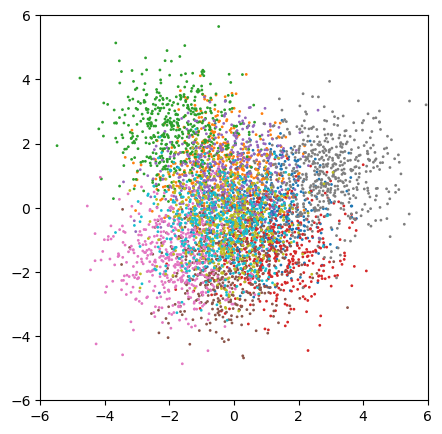

In [33]:
plt.figure(figsize = [5,5])
plt.scatter(pca[:,0], pca[:,1], c = labels, cmap = cmap, s = 1)
plt.xlim(-6,6)
plt.ylim(-6,6)
plt.xticks(np.linspace(-6,6,7))
plt.yticks(np.linspace(-6,6,7))
plt.savefig('../figures/gmm/pca.png', format='png', dpi=300, bbox_inches='tight')

In [34]:
st = time.time()
isomap = Isomap(n_neighbors=5).fit_transform(data)
time.time()-st

9.206297874450684

In [35]:
st = time.time()
umap = UMAP().fit_transform(data)
time.time()-st

39.4641273021698

In [36]:
st = time.time()
phate = PHATE().fit_transform(data)
time.time()-st

Calculating PHATE...
  Running PHATE on 5000 observations and 10 variables.
  Calculating graph and diffusion operator...
    Calculating KNN search...
    Calculated KNN search in 0.47 seconds.
    Calculating affinities...
    Calculated affinities in 1.28 seconds.
  Calculated graph and diffusion operator in 1.76 seconds.
  Calculating landmark operator...
    Calculating SVD...
    Calculated SVD in 0.80 seconds.
    Calculating KMeans...
    Calculated KMeans in 3.59 seconds.
  Calculated landmark operator in 4.40 seconds.
  Calculating optimal t...
    Automatically selected t = 13
  Calculated optimal t in 3.26 seconds.
  Calculating diffusion potential...
  Calculated diffusion potential in 0.63 seconds.
  Calculating metric MDS...
  Calculated metric MDS in 7.16 seconds.
Calculated PHATE in 18.18 seconds.


18.199543237686157

([<matplotlib.axis.YTick at 0x1abb2aa3f90>,
 [Text(0, -12.0, '−12'),
  Text(0, -8.0, '−8'),
  Text(0, -4.0, '−4'),
  Text(0, 0.0, '0'),
  Text(0, 4.0, '4'),
  Text(0, 8.0, '8'),
  Text(0, 12.0, '12')])

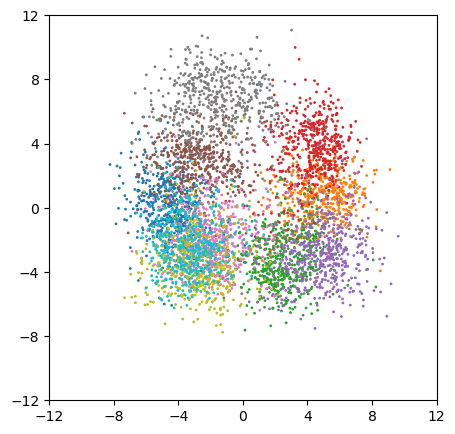

In [37]:
plt.figure(figsize = [5,5])
plt.scatter(isomap[:,0], isomap[:,1], c = labels, cmap = cmap, s = 1)
plt.xlim(-12,12)
plt.ylim(-12,12)
plt.xticks(np.linspace(-12,12,7))
plt.yticks(np.linspace(-12,12,7))
plt.savefig('../figures/gmm/isomap.png', format='png', dpi=300, bbox_inches='tight')

In [38]:
umap_ = umap - np.mean(umap, axis = 0)

([<matplotlib.axis.YTick at 0x1abb2a00a90>,
 [Text(0, -12.0, '−12'),
  Text(0, -8.0, '−8'),
  Text(0, -4.0, '−4'),
  Text(0, 0.0, '0'),
  Text(0, 4.0, '4'),
  Text(0, 8.0, '8'),
  Text(0, 12.0, '12')])

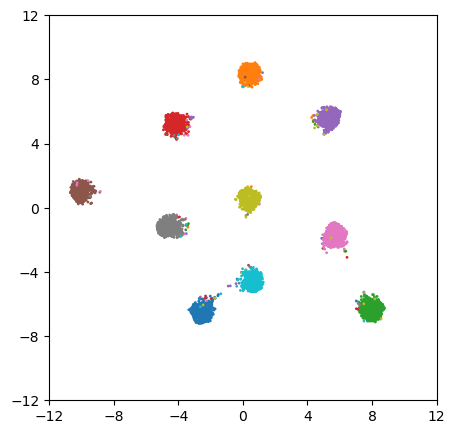

In [39]:
plt.figure(figsize = [5,5])
plt.scatter(umap_[:,0], umap_[:,1], c = labels, cmap = cmap, s = 1)
plt.xlim(-12,12)
plt.ylim(-12,12)
plt.xticks(np.linspace(-12,12,7))
plt.yticks(np.linspace(-12,12,7))
plt.savefig('../figures/gmm/umap.png', format='png', dpi=300, bbox_inches='tight')

([<matplotlib.axis.YTick at 0x1abb2a69f90>,
 [Text(0, -0.03, '−0.03'),
  Text(0, -0.019999999999999997, '−0.02'),
  Text(0, -0.009999999999999998, '−0.01'),
  Text(0, 0.0, '0.00'),
  Text(0, 0.010000000000000002, '0.01'),
  Text(0, 0.020000000000000004, '0.02'),
  Text(0, 0.03, '0.03')])

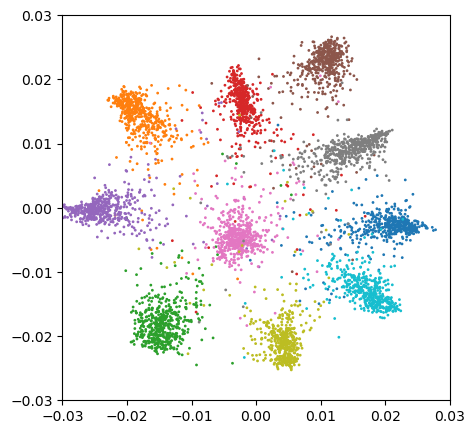

In [40]:
plt.figure(figsize = [5,5])
plt.scatter(phate[:,0], phate[:,1], c = labels, cmap = cmap, s = 1)
plt.xlim(-.03,.03)
plt.ylim(-.03,.03)
plt.xticks(np.linspace(-.03,.03,7))
plt.yticks(np.linspace(-.03,.03,7))
plt.savefig('../figures/gmm/phate.png', format='png', dpi=300, bbox_inches='tight')

In [ ]:
trimap =  np.load("../results/gmm/trimap.npy", allow_pickle=False)

([<matplotlib.axis.YTick at 0x1abb27e5310>,
 [Text(0, -54.0, '−54'),
  Text(0, -36.0, '−36'),
  Text(0, -18.0, '−18'),
  Text(0, 0.0, '0'),
  Text(0, 18.0, '18'),
  Text(0, 36.0, '36'),
  Text(0, 54.0, '54')])

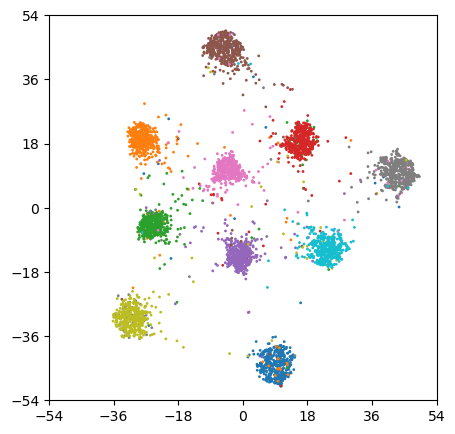

In [41]:
plt.figure(figsize = [5,5])
plt.scatter(trimap[:,0], trimap[:,1], c = labels, cmap = cmap, s = 1)
plt.xlim(-54,54)
plt.ylim(-54,54)
plt.xticks(np.linspace(-54,54,7))
plt.yticks(np.linspace(-54,54,7))
plt.savefig('../figures/gmm/trimap.png', format='png', dpi=300, bbox_inches='tight')

In [57]:
all_embs = [ce_emb, ce_emb_2, ce_emb_165, tsne30, pca, isomap, umap, phate, trimap]
results = [all_embs, labels, clusters]

with open('../results/gmm/embeddings.pkl', 'wb') as file:  
    pickle.dump(results, file)

# Evaluation

In [3]:
# load embeddings
with open('../results/gmm/embeddings.pkl', 'rb') as file:  
    results = pickle.load( file)
ce_emb, ce_emb_2, ce_emb_165, tsne30, pca, isomap, umap, phate,trimap = results[0]

all_embs = [ce_emb, ce_emb_2, ce_emb_165, tsne30, pca, isomap, umap, phate]

In [66]:
all_embs = [ce_emb, ce_emb_2, ce_emb_165, tsne30, pca, isomap, umap, phate, trimap]
orig_distances = squareform(pdist(data))
for emb in all_embs:
    emb_distances =  squareform(pdist(emb))
    spearman_scores = spearman(orig_distances, emb_distances, labels)
    stress_scores = normalized_stress(orig_distances, emb_distances, labels)
    class_score = class_preservation(orig_distances, emb_distances, labels)
    scaled_stress_scores =  scale_normalized_stress(orig_distances, emb_distances, labels)
    recall_score = knn_recall(data, emb, [30])
    
    formatted = " & ".join(
    [
        f"${spearman_scores[0]:.2f}$",
        f"${stress_scores[0]:.2f}$",
        f"${scaled_stress_scores[0]:.2f}$",
        f"${recall_score[0]:.2f}$",
        *[f"${x:.2f}$" for x in spearman_scores[1:]],
        *[f"${x:.2f}$" for x in stress_scores[1:]],
        *[f"${x:.2f}$" for x in scaled_stress_scores[1:]],
        f"${class_score:.2f}$"
    ]
)


    print(formatted)
    print()

$0.48$ & $0.58$ & $0.47$ & $0.12$ & $0.20$ & $0.31$ & $0.37$ & $0.40$ & $0.29$ & $0.40$ & $0.04$

$0.49$ & $0.67$ & $0.66$ & $0.17$ & $0.23$ & $0.31$ & $0.86$ & $0.96$ & $0.23$ & $0.39$ & $0.25$

$0.49$ & $0.64$ & $0.62$ & $0.17$ & $0.23$ & $0.31$ & $0.65$ & $0.73$ & $0.24$ & $0.40$ & $-0.11$

$0.39$ & $3.14$ & $0.63$ & $0.33$ & $0.26$ & $0.33$ & $8.07$ & $8.46$ & $0.22$ & $0.40$ & $0.54$

$0.42$ & $0.62$ & $0.41$ & $0.06$ & $0.43$ & $0.41$ & $0.59$ & $0.60$ & $0.35$ & $0.42$ & $0.49$

$0.27$ & $0.51$ & $0.49$ & $0.07$ & $0.27$ & $0.32$ & $0.46$ & $0.48$ & $0.32$ & $0.44$ & $0.18$

$0.35$ & $0.86$ & $0.86$ & $0.23$ & $0.20$ & $0.28$ & $0.56$ & $0.67$ & $0.21$ & $0.42$ & $0.26$

$0.27$ & $1.00$ & $0.67$ & $0.16$ & $0.40$ & $0.37$ & $1.00$ & $1.00$ & $0.21$ & $0.39$ & $0.39$

$0.34$ & $2.07$ & $0.77$ & $0.22$ & $0.25$ & $0.31$ & $5.56$ & $5.96$ & $0.20$ & $0.42$ & $0.60$



In [59]:
recall_results = []

for emb in all_embs:
    recall_score = knn_recall(data, emb, np.arange(5,250,5))
    recall_results += [recall_score]

In [61]:
colors = ['#3182bd', '#aec7e8', 'gray', '#ff7f0e', '#d62728', '#31a354',  '#8c564b','#9467bd', '#e377c2']



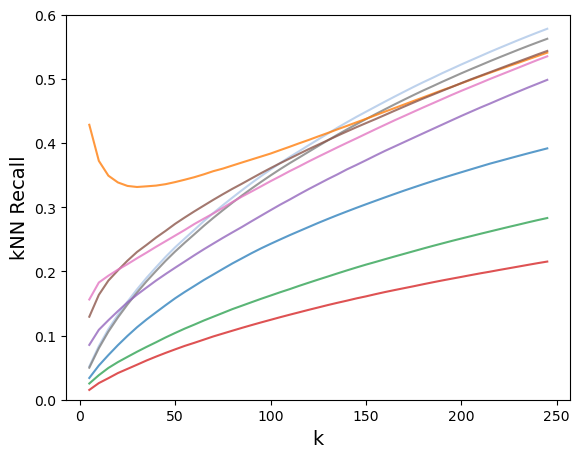

In [62]:
plt.figure(figsize = [6.5,5])
method_labels  = [r'C+E ($\alpha = 1$)', r'C+E ($\alpha = 2$)', r'C+E ($\alpha = 1.65$)', 't-SNE (u = 30)',
          'PCA', 'Isomap', 'UMAP', 'PHATE', 'TriMap']
for i,r in enumerate(recall_results):
    plt.plot(np.arange(5,250,5), r, label = method_labels[i], color = colors[i], alpha = .8)
# plt.legend()
plt.xlabel('k', fontsize = 14)
plt.ylabel('kNN Recall', fontsize = 14)
plt.ylim(0,0.6)
# 
plt.savefig('../figures/gmm/knn.png', format='png', dpi=300, bbox_inches='tight')

In [63]:

with open('../results/gmm/knn.pkl', 'wb') as file:  
    pickle.dump(recall_results, file)